## Section 1 - Load the data

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Section 2 - Inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

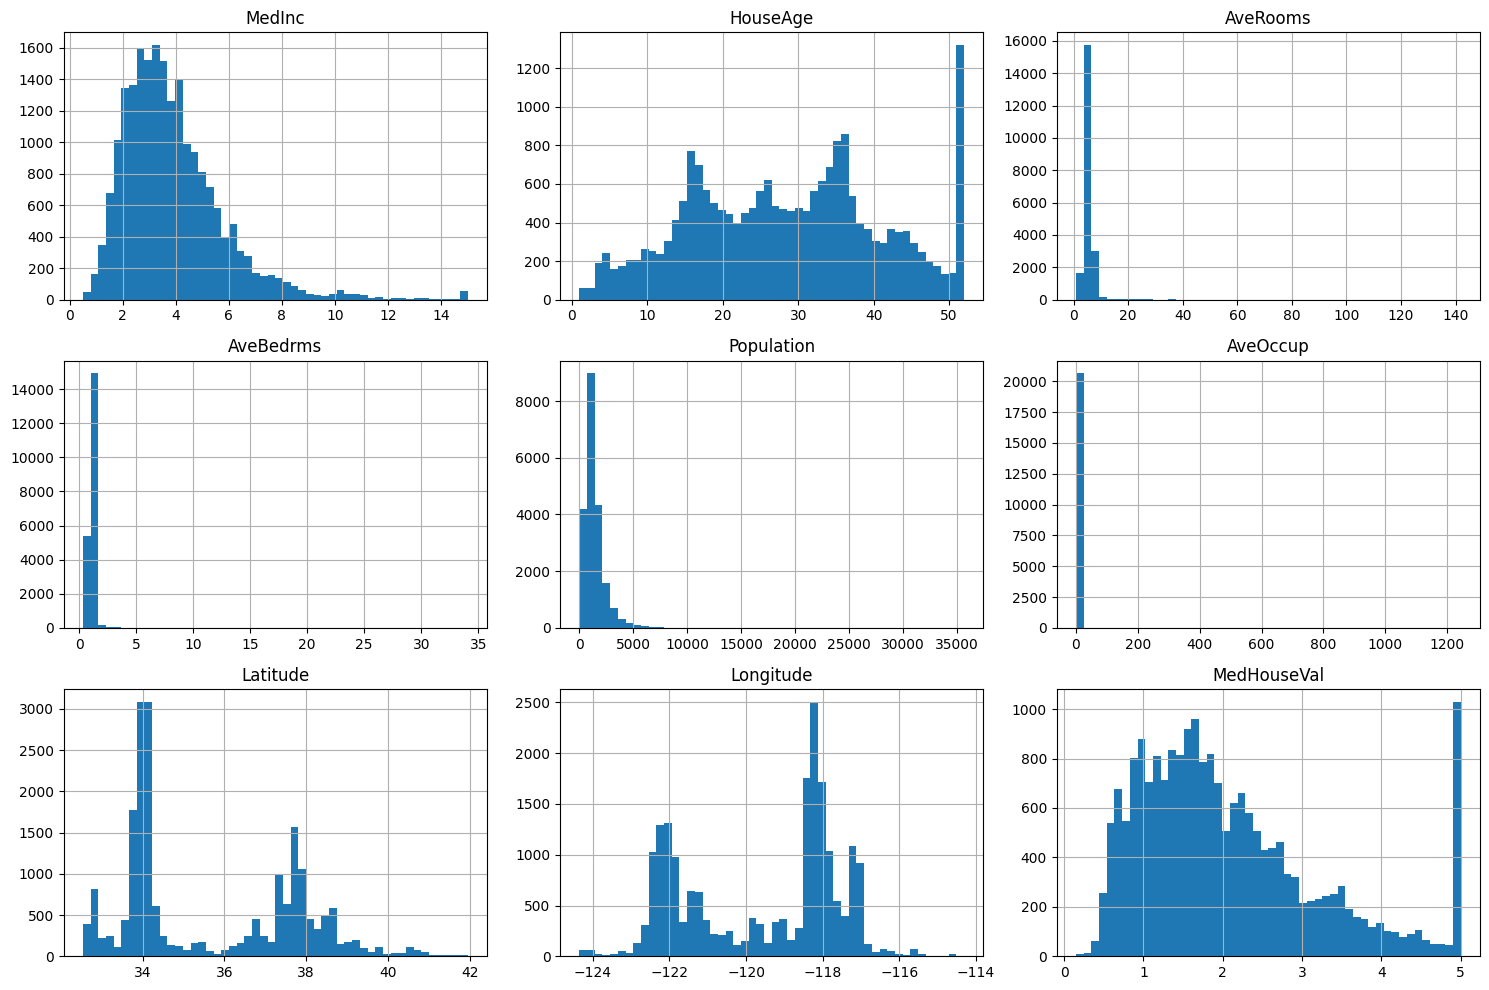

In [5]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [6]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

##### Observations from the Feature Distributions

- **`MedInc` (median income) is likely the feature most strongly correlated with `MedHouseVal`**, making it one of the most informative predictors for California housing prices in the 1990s.

- Several variables are **capped/truncated due to dataset collection limits**:
  - `HouseAge` capped at **52**
  - `MedHouseVal` capped at **5.0**
  - `MedInc` capped at approximately **15.0001** (upper bound) and **0.4999** (lower bound)
  
  These caps are known quirks of the original California census-derived dataset and can distort distributions near the boundaries.

- Features such as `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` show **extreme right-skewness** with long tails, suggesting highly uneven neighborhood characteristics.

- There are clear **outliers/anomalous districts**:
  - `AveOccup` exceeding **1000**
  - `Population` above **35,000**
  - `AveRooms` above **140**
  
  These values are unusually large for typical residential blocks and may require outlier handling or transformation.

- `Latitude` and `Longitude` show **clustered geographic patterns** rather than smooth distributions, which likely reflects dense population centers and coastal urban regions in California.

## Section 3 - Train/test split

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16512, 8), Test: (4128, 8)


- The test is set aside. It is not touched until the end of the model evaluation. Looking at it during development causes data leakage.

## Section 4 - Baseline linear regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Train RMSE: {rmse_train:.4f}")

Train RMSE: 0.7197


- The training **RMSE** is *0.7197*, and since the target variable is measured units of *100,000*, this corresponds to an average prediction error of about *71,970* for a typical house. In practical terms, the model's predicted median house value is usually off by roughly *$72k* from the actual value.

## Section 5 - Gradient descent from scratch
- The goal is to implement batch gradient descent in pure np on the California Housing data, with no scikit-learn for the optimizer. Then verify it matches what **LinearRegression** gave you.

### 5a - Prepare the data
Linear regression with gradient descent needs:

Features as a NumPy matrix X with a column of ones prepended (so the bias term is folded into θ).
Target as a NumPy vector y.
Standardized features - critical. Without scaling, the loss surface is so elongated that no single learning rate works for all parameters. With scaling, all parameters are on similar scales and a single η behaves reasonably.

In [9]:
from sklearn.preprocessing import StandardScaler

# Standardize (fit on train only - same rules as always)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Add bias column of ones (so theta becomes the intercept)
X_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
y_b = y_train.values # convert pandas Series to NumPy array

print(f"X_b shape: {X_b.shape}") #should be (16512, 9) - 8 features + 1 bias
print(f"y_b shape: {y_b.shape}") #should be (16512,)

X_b shape: (16512, 9)
y_b shape: (16512,)


### 5b - Implement gradient descent

In [10]:
def gradient_descent(X, y, eta=0.01, n_iterations=1000):
    """
    Batch gradient descent for linear regression.

    Returns: (theta_final, loss_history)
    """
    m = len(y)
    theta = np.zeros(X.shape[1])  # start at zero
    loss_history = []

    for i in range(n_iterations):
        # Predictions and residuals
        y_pred = X @ theta
        residuals = y_pred - y

        # MSE loss for tracking
        loss = (residuals ** 2).mean()
        loss_history.append(loss)

        # Gradient: d/dtheta of (1/m) * sum((X@theta - y)^2)
        gradient = (2 / m) * X.T @ residuals

        # Update step
        theta = theta - eta * gradient

    return theta, loss_history

In [11]:
theta_gd, loss_history = gradient_descent(X_b, y_b, eta=0.01, n_iterations=1000)

print(f"Final theta (first 3 entries): {theta_gd[:3]}")
print(f"Final loss (MSE): {loss_history[-1]:.4f}")
print(f"Final RMSE: {np.sqrt(loss_history[-1]):.4f}")

Final theta (first 3 entries): [2.07194693 0.8580605  0.1501549 ]
Final loss (MSE): 0.5246
Final RMSE: 0.7243


### 5c - Plot the loss curve

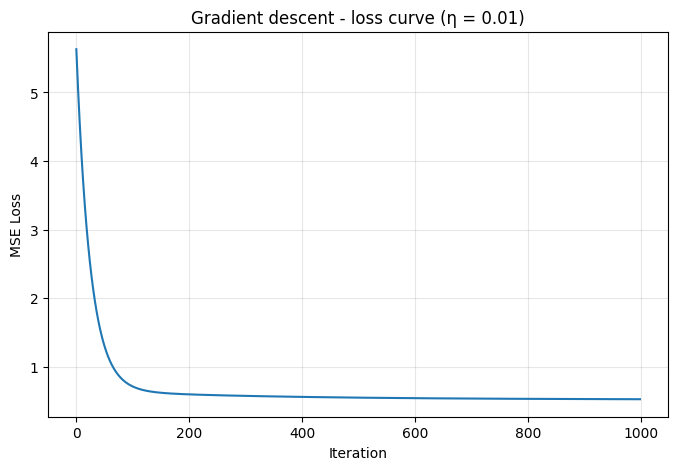

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient descent - loss curve (η = 0.01)")
plt.grid(True, alpha=0.3)
plt.show()

### 5d - Verify against scikit-learn

In [17]:
# scikit-learn closed-form solution on the SAME standardized feature
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)

print("Hand-coded gradient descent (after 1000 iterations, η=0.01):")
print(f" Intercept: {theta_gd[0]:.4f}")
print(f" First 3 coefs: {theta_gd[1:4]}")
print()
print("scikit-learn (closed-form normal equations):")
print(f" Intercept: {sk_model.intercept_:.4f}")
print(f" First 3 coefs {sk_model.coef_[:3]}")

Hand-coded gradient descent (after 1000 iterations, η=0.01):
 Intercept: 2.0719
 First 3 coefs: [ 0.8580605   0.1501549  -0.25253771]

scikit-learn (closed-form normal equations):
 Intercept: 2.0719
 First 3 coefs [ 0.85438303  0.12254624 -0.29441013]


The two solutions are very close, specially considering the gradient descent model was trained with a finxed laerning rate η = 0.01 and only 1000 iterations. This tells us that the hand-coded gradient descent implementation is working correctly, and the gradient descent is an iterative approximation method. However, the remaining differences suggest that the algorithm has not fully converged yet, or the learning rate/iteration count could be improved.

### 5e - Learning rate experiments

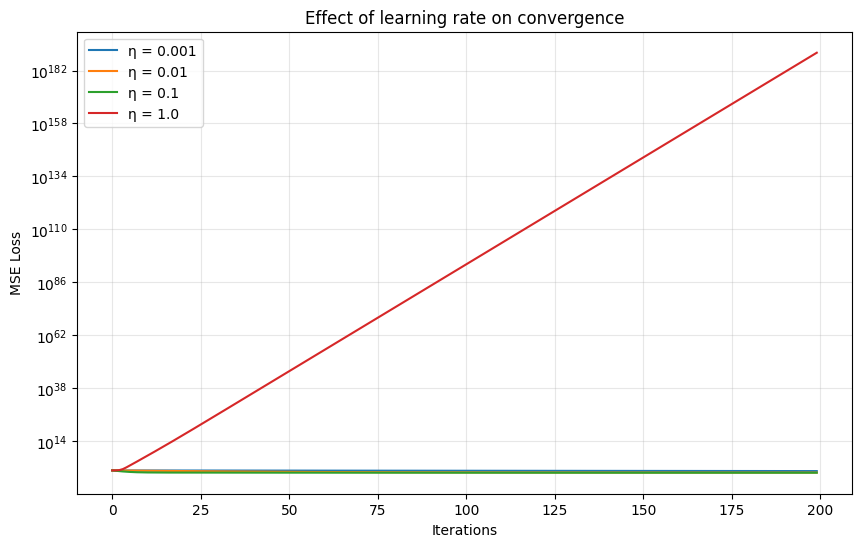

In [22]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
plt.figure(figsize=(10, 6))

for eta in learning_rates:
    _, history = gradient_descent(X_b, y_b, eta=eta, n_iterations=200)
    plt.plot(history, label=f"η = {eta}")

plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.yscale("log") # log scale makes both convergences and divergences visible
plt.grid(True, alpha=0.3)
plt.show()

The learning rate in gradient descent plays a role similar to the damping parameter in the Lavenberg-Marquardt algorithm because both control how aggressively the parametrs are updated during optimization. However, Levenberg-Marquardt is more robust because it adaptively balances between gradient descent and Gauss-Newton updates using curvature information from Jacobian. In practice, this makes LM much more stable and efficient near the optimum, while still remaining cautious when the solution is far from convergence.
 modern ML optimizers (Adam, RMSprop) are also adaptive but they adapt differently. LM uses curvature explicitly (the Jacobian). Adam approximates curvature implicitly using running averages of past gradients squared. Same goal, adaptive step sizes, different mechanism. If you find yourself in an interview discussing this, that's the bridge to draw: "LM-style adaptive methods exist in ML, they just go by different names and use different curvature estimates."